In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet import preprocess_input

In [2]:
val_dir = "Dataset/val"

In [3]:
from tensorflow.keras.models import load_model

model = load_model("mobilenet_model.h5")

In [4]:

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

val_ds = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=64,
    class_mode="binary",
    shuffle=False   # BẮT BUỘC để vẽ confusion matrix đúng
)


Found 1201 images belonging to 2 classes.


In [5]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [6]:
import numpy as np

y_pred_prob = model.predict(val_ds)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()


c:\Users\vhgam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step


In [7]:
y_true = val_ds.classes


In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)


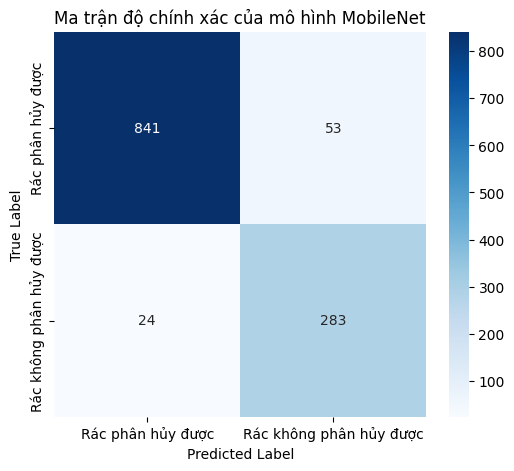

In [10]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rác phân hủy được", "Rác không phân hủy được"],
    yticklabels=["Rác phân hủy được", "Rác không phân hủy được"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Ma trận độ chính xác của mô hình MobileNet")
plt.show()
